***Overlaying the prior (posterior) distribution***

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

def plot_universality_overlay(
    idf,
    base_dir,
    xT_experimental,
    ratios_experimental,
    ratios_uncertainties,
    posterior_samples=None,
    Emulators=None,
    inverse_tf_matrix=None,
    scaler=None,
    n_prior_samples=1000,
    n_posterior_samples=500,
    save_folder="universality"
):
    # load model calc_data: shape = (n_design, n_model_cent, n_xt)
    calc_data = load_moment_data(base_dir, idf)
    n_design, n_model_cent, n_xt = calc_data.shape

    # experimental arrays: may have more classes, but we only use first n_model_cent
    xT_ref = np.array(xT_experimental[0])  # 0–5% grid
#    n_cent = n_model_cent # 10 centralities
    n_cent = 7
    
    # setup figure
    fig, ax = plt.subplots(figsize=(8,6), dpi=1200)

    # plot prior & posterior per centrality
    for cent in range(1, n_cent):
        # collect prior
        prior_ratios = []
        for i in range(min(n_prior_samples, n_design)):
            U0 = calc_data[i, 0, :]
            Ui = calc_data[i, cent, :]
            f0 = interpolate.interp1d(xT_ref, U0,    fill_value="extrapolate")
            fi = interpolate.interp1d(xT_experimental[cent], Ui, fill_value="extrapolate")
            prior_ratios.append(fi(xT_ref) / f0(xT_ref))
        prior = np.stack(prior_ratios)
        p_lo, p_hi = np.percentile(prior, [5,95], axis=0)
#        p_md       = np.median(prior, axis=0)
        ax.fill_between(xT_ref, p_lo, p_hi,
                        color='gray', alpha=0.7)
#        ax.plot(xT_ref, p_md, '--', color='gray', alpha=0.7)

        # posterior
        if posterior_samples is not None and Emulators is not None:
            post_ratios = []
            samp = posterior_samples.sample(n=min(n_posterior_samples, len(posterior_samples)))
            for _, row in samp.iterrows():
                y_pred, _ = predict_observables(
                    row.values, Emulators, inverse_tf_matrix, scaler
                )
                y_pred = y_pred.flatten().reshape(n_cent, n_xt)
                U0, Ui = y_pred[0], y_pred[cent]
                f0 = interpolate.interp1d(xT_ref, U0,    fill_value="extrapolate")
                fi = interpolate.interp1d(xT_experimental[cent], Ui, fill_value="extrapolate")
                post_ratios.append(fi(xT_ref) / f0(xT_ref))
            post = np.stack(post_ratios)
            q_lo, q_hi = np.percentile(post, [5,95], axis=0)
#            q_md       = np.median(post, axis=0)
            ax.fill_between(xT_ref, q_lo, q_hi,
                            color=color_map[idf], alpha=0.2)
#            ax.plot(xT_ref, q_md, color=color_map[idf], lw=2)

        # experimental
#        ax.errorbar(
#            xT_experimental[cent],
#            ratios_experimental[cent],
#            yerr=ratios_uncertainties[cent],
#            fmt='o',
#            color='k', 
#            capsize=1,
#            label=f"{centrality_classes[cent]}%"
#        )
    # formatting
    ax.axhline(1, ls='--', color='k', lw=1)
    ax.set_xscale('log')
    ax.set_xlim(xT_ref.min(), xT_ref.max())
    ax.set_ylim(0.4, 2)
    ax.set_xlabel(r"$x_T$")
    ax.set_ylabel(r"$U/U_{0-5\%}$")
    ax.set_title(f"Universality Ratio ({idf_label_short[idf]})")
    ax.legend(ncol=2, fontsize=9)
    ax.grid(True, ls='--', alpha=0.3)
    plt.show()

    # save
#    out_dir = os.path.join(save_folder, f"idf_{idf}")
#    os.makedirs(out_dir, exist_ok=True)
#    out_file = os.path.join(out_dir, f"univ_ratio_overlay_idf{idf}.pdf")
#    fig.savefig(out_file, bbox_inches='tight')
#    plt.close(fig)
#    print(f"Saved overlay to {out_file}")
#    return out_file
centrality_classes=['0-5','5-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90']
xT=[[0.21215043,0.25072324,0.28929605,0.32786885,0.36644166,0.43394407,0.53037608,0.6268081,0.72324012,0.81967213,0.91610415,1.01253616,1.10896818,1.20540019,1.30183221,1.39826422,1.49469624,1.59112825,1.68756027,1.78399229,1.8804243,2.02507232,2.21793635,2.41080039,2.60366442,2.79652845,2.98939248,3.18225651,3.37512054,3.56798457,3.7608486,3.95371263,4.14657666,4.33944069,4.53230473,4.72516876,4.91803279,5.11089682,5.30376085,5.49662488,5.68948891],[0.21194605,0.2504817,0.28901734,0.32755299,0.36608863,0.43352601,0.52986513,0.62620424,0.72254335,0.81888247,0.91522158,1.01156069,1.10789981,1.20423892,1.30057803,1.39691715,1.49325626,1.58959538,1.68593449,1.7822736,1.87861272,2.02312139,2.21579961,2.40847784,2.60115607,2.7938343,2.98651252,3.17919075,3.37186898,3.56454721,3.75722543,3.94990366,4.14258189,4.33526012,4.52793834,4.72061657,4.9132948,5.10597303,5.29865125,5.49132948,5.68400771],[0.21194605,0.2504817,0.28901734,0.32755299,0.36608863,0.43352601,0.52986513,0.62620424,0.72254335,0.81888247,0.91522158,1.01156069,1.10789981,1.20423892,1.30057803,1.39691715,1.49325626,1.58959538,1.68593449,1.7822736,1.87861272,2.02312139,2.21579961,2.40847784,2.60115607,2.7938343,2.98651252,3.17919075,3.37186898,3.56454721,3.75722543,3.94990366,4.14258189,4.33526012,4.52793834,4.72061657,4.9132948,5.10597303,5.29865125,5.49132948,5.68400771],[0.21400778,0.25291829,0.29182879,0.3307393,0.36964981,0.43774319,0.53501946,0.63229572,0.72957198,0.82684825,0.92412451,1.02140078,1.11867704,1.21595331,1.31322957,1.41050584,1.5077821,1.60505837,1.70233463,1.79961089,1.89688716,2.04280156,2.23735409,2.43190661,2.62645914,2.82101167,3.0155642,3.21011673,3.40466926,3.59922179,3.79377432,3.98832685,4.18287938,4.37743191,4.57198444,4.76653696,4.96108949,5.15564202,5.35019455,5.54474708,5.73929961],[0.21760633,0.25717112,0.29673591,0.33630069,0.37586548,0.44510386,0.54401583,0.64292779,0.74183976,0.84075173,0.9396637,1.03857567,1.13748764,1.2363996,1.33531157,1.43422354,1.53313551,1.63204748,1.73095945,1.82987141,1.92878338,2.07715134,2.27497527,2.47279921,2.67062315,2.86844708,3.06627102,3.26409496,3.46191889,3.65974283,3.85756677,4.0553907,4.25321464,4.45103858,4.64886251,4.84668645,5.04451039,5.24233432,5.44015826,5.6379822,5.83580613],[0.22244692,0.26289181,0.3033367,0.3437816,0.38422649,0.45500506,0.55611729,0.65722952,0.75834176,0.85945399,0.96056623,1.06167846,1.1627907,1.26390293,1.36501517,1.4661274,1.56723964,1.66835187,1.76946411,1.87057634,1.97168857,2.12335693,2.3255814,2.52780586,2.73003033,2.9322548,3.13447927,3.33670374,3.53892821,3.74115268,3.94337715,4.14560162,4.34782609,4.55005056,4.75227503,4.95449949,5.15672396,5.35894843,5.5611729,5.76339737,5.96562184],[0.2289282,0.27055151,0.31217482,0.35379813,0.39542144,0.46826223,0.5723205,0.67637877,0.78043704,0.88449532,0.98855359,1.09261186,1.19667014,1.30072841,1.40478668,1.50884495,1.61290323,1.7169615,1.82101977,1.92507804,2.02913632,2.18522373,2.39334027,2.60145682,2.80957336,3.01768991,3.22580645,3.433923,3.64203954,3.85015609,4.05827263,4.26638918,4.47450572,4.68262227,4.89073881,5.09885536,5.3069719,5.51508845,5.72320499,5.93132154,6.13943809],[0.23529412,0.27807487,0.32085561,0.36363636,0.40641711,0.48128342,0.58823529,0.69518717,0.80213904,0.90909091,1.01604278,1.12299465,1.22994652,1.3368984,1.44385027,1.55080214,1.65775401,1.76470588,1.87165775,1.97860963,2.0855615,2.2459893,2.45989305,2.67379679,2.88770053,3.10160428,3.31550802,3.52941176,3.74331551,3.95721925,4.17112299,4.38502674,4.59893048,4.81283422,5.02673797,5.24064171,5.45454545,5.6684492,5.88235294,6.09625668,6.31016043],[0.24255788,0.28665932,0.33076075,0.37486218,0.41896362,0.49614112,0.60639471,0.71664829,0.82690187,0.93715546,1.04740904,1.15766262,1.26791621,1.37816979,1.48842337,1.59867696,1.70893054,1.81918412,1.92943771,2.03969129,2.14994487,2.31532525,2.53583241,2.75633958,2.97684675,3.19735391,3.41786108,3.63836825,3.85887541,4.07938258,4.29988975,4.52039691,4.74090408,4.96141125,5.18191841,5.40242558,5.62293275,5.84343991,6.06394708,6.28445424,6.50496141],[0.25200458,0.2978236,0.34364261,0.38946163,0.43528064,0.51546392,0.63001145,0.74455899,0.85910653,0.97365407,1.0882016,1.20274914,1.31729668,1.43184422,1.54639175,1.66093929,1.77548683,1.89003436,2.0045819,2.11912944,2.23367698,2.40549828,2.63459336,2.86368843,3.09278351,3.32187858,3.55097365,3.78006873,4.0091638,4.23825888,4.46735395,4.69644903,4.9255441,5.15463918,5.38373425,5.61282932,5.8419244,6.07101947,6.30011455,6.52920962,6.7583047]]
U_xT_ratios=[[1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.],[0.99212189,0.98176755,0.98307631,0.99205244,0.984027,1.00912513,1.00703253,1.00638534,1.00824875,1.00523946,1.00820496,0.99112851,0.99228336,0.99386802,0.99201651,0.99891989,0.99180681,0.99490301,1.00151065,0.99690049,0.9911244,0.99967504,0.99544152,0.99271021,0.99394593,0.99605267,1.00435109,0.99872795,0.99874636,1.00204439,1.00879312,1.0053233,1.01235574,1.02315089,1.01169808,1.01875078,1.02785821,1.01041896,1.05536579,1.04388088,1.0381409],[0.99125725,0.99093859,0.98781035,0.99469451,0.98680867,1.01645556,1.0099084,1.00415813,1.00546625,1.00302176,1.00238724,0.98705014,0.98765258,0.98859952,0.98621001,0.99083712,0.98629791,0.98693829,0.99082217,0.99214752,0.99068925,0.99467635,0.99649545,0.98760472,0.98873687,1.00499557,1.00766932,1.00333542,1.01184894,1.01131116,1.02140121,1.01584591,1.02791345,1.04567552,1.04136474,1.04487465,1.07546144,1.09380923,1.09157716,1.08338072,1.07882386],[1.00834829,0.99204605,0.99978412,1.00867267,0.99823855,1.01582727,1.00958659,1.00037758,0.99693593,0.99525866,0.99105336,0.97755381,0.97561875,0.97468912,0.97360652,0.97933343,0.9740168,0.97684591,0.97963037,0.98245854,0.98090287,0.98627341,0.98676523,0.98228168,0.98479082,1.0055581,1.02099957,1.02271064,1.0305555,1.03654439,1.0404762,1.06410942,1.07726973,1.10385865,1.08096315,1.13000197,1.12319467,1.14717515,1.18129303,1.17568761,1.18823712],[1.0165718,1.00225844,1.00942326,1.01171367,1.00627272,1.01801999,1.00824799,0.99701731,0.99191537,0.98858843,0.98128962,0.96605927,0.96051412,0.96478824,0.96381642,0.96139854,0.9606313,0.96475092,0.96256266,0.9647577,0.96844902,0.96964007,0.9702959,0.96904752,0.9827824,1.00238653,1.023381,1.02438821,1.04697581,1.05339988,1.07396763,1.09908395,1.14146292,1.12682816,1.14871235,1.21316435,1.20329084,1.24310295,1.24427051,1.29440042,1.33986227],[1.03940196,1.01895729,1.02533242,1.01520951,1.02295377,1.02731155,1.01586325,1.00403511,0.99148254,0.98701443,0.98268332,0.96057099,0.95433642,0.95386326,0.95818797,0.95282818,0.95192708,0.95435584,0.95693004,0.95500712,0.95250756,0.95439467,0.95526436,0.9747273,0.98031823,1.00845105,1.03490602,1.0488511,1.06948898,1.09443633,1.12385207,1.16754045,1.18254947,1.20812576,1.23901983,1.28691554,1.31960908,1.3619866,1.45796598,1.43155708,1.59839473],[1.03371307,1.03136478,1.04189153,1.02425534,1.02994622,1.03654665,1.02061918,1.00221379,0.98927533,0.98270808,0.97154527,0.95248128,0.93989869,0.94560828,0.94479093,0.94010751,0.94096093,0.93923871,0.93057958,0.93998821,0.94745753,0.94426388,0.94611435,0.96465844,1.0010537,1.01142701,1.04248375,1.07733438,1.09214087,1.14829351,1.18539621,1.20884908,1.25516159,1.27910417,1.35570371,1.39721984,1.49417424,1.52217812,1.53733135,1.61550463,2.099312],[1.0362942,1.05405706,1.0390795,1.03823098,1.06033081,1.04569242,1.02589563,1.00956363,0.98496305,0.98261679,0.96674042,0.94251465,0.92838444,0.92886758,0.92579186,0.92651063,0.91458939,0.92431782,0.91398247,0.92221047,0.92207178,0.92652719,0.92345434,0.95260745,0.99133803,1.00885506,1.04885622,1.10382735,1.11431166,1.19224774,1.24376068,1.27418187,1.33196294,1.38722144,1.47716096,1.53863093,1.6138456,1.66914024,1.77542724,2.04278606,3.07198689],[1.07579626,1.05018038,1.03974725,1.0323234,1.08132792,1.05984329,1.0356068,1.00850334,0.98877802,0.97483654,0.95791258,0.93144337,0.92164092,0.92045232,0.91793827,0.90906969,0.89587116,0.89381867,0.90075549,0.90019444,0.91653545,0.90651718,0.9339457,0.94948574,1.00378786,1.04254022,1.07258109,1.1286765,1.15357675,1.24684978,1.3283936,1.34187769,1.45095557,1.50713584,1.56874427,1.67075915,1.74032829,1.87919578,2.13474775,3.08097486,8.18087006],[1.02937051,1.04541699,1.03122067,1.06166564,1.08349452,1.09470481,1.05884016,1.03823895,1.01361936,0.99464515,0.97282835,0.93715081,0.92209546,0.92338648,0.91244016,0.90124944,0.9071594,0.88647144,0.86920525,0.90318733,0.89162476,0.90387072,0.92670181,0.95775217,0.98979986,1.0158362,1.06986393,1.12973251,1.15069727,1.26275439,1.30100188,1.38803538,1.50407289,1.5527221,1.64732166,1.76017378,1.99511176,2.37426167,3.16378579,9.60596765,-5.36633145]]
U_xT_ratios_uncertainties=[[0.1249408,0.12031706,0.11998557,0.11985535,0.12001958,0.09651751,0.09660579,0.09777901,0.09553545,0.09489954,0.09442881,0.088388,0.08782061,0.08842266,0.08861025,0.08861313,0.08893091,0.08899369,0.08927577,0.08942067,0.08915101,0.0896983,0.08962013,0.09139852,0.09145335,0.09175417,0.09202753,0.09241303,0.09279282,0.09326106,0.09397325,0.09477712,0.09574422,0.09650873,0.09764392,0.09978629,0.10115789,0.10366472,0.10419284,0.10590319,0.10904156],[0.11865703,0.11269834,0.11265902,0.11359851,0.11271451,0.09333393,0.09279933,0.09446892,0.09233086,0.09149617,0.09145332,0.08415623,0.08383635,0.08481639,0.08461678,0.08499717,0.08425163,0.08433354,0.08504978,0.08454714,0.08412242,0.0848842,0.08498603,0.08779444,0.08796935,0.08834286,0.08933144,0.08924515,0.08961739,0.09051265,0.091902,0.09244184,0.09398996,0.09580721,0.09590813,0.09881689,0.10112379,0.10209789,0.10723423,0.10793479,0.11092243],[0.11470693,0.10982285,0.10921752,0.1099003,0.10904297,0.09213908,0.09131854,0.09236892,0.09032325,0.08951338,0.08932846,0.08244405,0.08198893,0.08293326,0.08265056,0.08296853,0.08253343,0.08247968,0.08287513,0.08273649,0.08264501,0.08304707,0.0830993,0.08611003,0.08630014,0.08791747,0.08840846,0.08842762,0.08951572,0.09006514,0.09186682,0.09199737,0.09415263,0.09661031,0.0974392,0.10003343,0.10445121,0.10916921,0.10949947,0.1105174,0.11362713],[0.11231228,0.10539857,0.10605107,0.10689639,0.10574933,0.08937972,0.08863623,0.08927957,0.08694145,0.08627373,0.08570189,0.07919703,0.07854657,0.07980074,0.07954056,0.07980685,0.07942397,0.07956936,0.07971701,0.07983199,0.07972573,0.08018265,0.08016932,0.08359974,0.08393309,0.08591944,0.08750936,0.08797441,0.08918121,0.09025882,0.09144425,0.09429163,0.09660184,0.09996604,0.09904049,0.10619045,0.1072038,0.11254637,0.11650652,0.11796756,0.12334849],[0.11120284,0.10448001,0.1049659,0.1050709,0.10450568,0.08967692,0.08875037,0.08893077,0.08674297,0.08594391,0.08517367,0.07865873,0.07794269,0.07955939,0.07941083,0.07912841,0.07904478,0.07923629,0.07935688,0.07926776,0.07949627,0.07949106,0.07962871,0.08326673,0.08452697,0.08640139,0.08846773,0.08896255,0.09141689,0.09257263,0.0952613,0.09830846,0.10327965,0.10298935,0.10617157,0.11506631,0.11576569,0.12300823,0.12384047,0.13106732,0.1403319],[0.11232391,0.10469831,0.10505282,0.10403943,0.10490209,0.09101102,0.08980911,0.09016197,0.08744827,0.08651941,0.08598252,0.07937789,0.07857648,0.07986068,0.08005822,0.0795283,0.07967686,0.07965221,0.07983519,0.07963137,0.07945002,0.07949273,0.07955831,0.08490723,0.08551754,0.08811901,0.0907981,0.09243037,0.09470641,0.09758815,0.10111823,0.10590457,0.10860505,0.11189692,0.11629403,0.12372507,0.12892741,0.13670743,0.14729991,0.1471204,0.16996309],[0.11019383,0.1045685,0.10525086,0.10338382,0.10407584,0.09218896,0.09081703,0.09025834,0.0875818,0.08652477,0.08546189,0.0796442,0.07855416,0.08016374,0.0797948,0.07952166,0.07972063,0.07947167,0.07864268,0.07954857,0.08009203,0.07949977,0.07957426,0.08485612,0.08826008,0.08939697,0.09244218,0.09605373,0.09785109,0.1036354,0.10801003,0.11106621,0.11683504,0.12028106,0.12917792,0.13653349,0.14864781,0.15532342,0.15837552,0.16896624,0.22798808],[0.10647673,0.10233674,0.10060096,0.10039527,0.10254201,0.08968327,0.0878087,0.08760569,0.08405164,0.08348919,0.08226322,0.07575731,0.0745948,0.07601976,0.07570721,0.07595631,0.07486831,0.07569274,0.07474209,0.07559813,0.07548435,0.07562441,0.07535593,0.08129777,0.08473905,0.08649391,0.09028935,0.09560993,0.0970328,0.10460377,0.11023245,0.11399171,0.12080029,0.12715374,0.13733389,0.14703054,0.15714341,0.16720942,0.17964087,0.21041236,0.32868552],[0.12113519,0.1127539,0.11136044,0.11039661,0.11569343,0.10430924,0.10176841,0.10001136,0.09720429,0.0954338,0.09371866,0.08758654,0.0866127,0.08792413,0.08783791,0.08670562,0.0856885,0.08646926,0.08602605,0.08705737,0.08842435,0.08708097,0.08964658,0.09343719,0.0989309,0.10302217,0.10629329,0.1123376,0.11532383,0.12546063,0.13480672,0.13725221,0.14993391,0.15717501,0.16573882,0.1803367,0.19094103,0.21109988,0.24211693,0.35491928,0.97376035],[0.13368656,0.13071859,0.12872437,0.13237491,0.13512673,0.1295654,0.12551919,0.12343332,0.11976431,0.11730825,0.11479802,0.10803713,0.10679452,0.1074785,0.10638527,0.10487083,0.10603672,0.10334209,0.10326452,0.10687837,0.10596175,0.10593114,0.11026697,0.11345878,0.11741506,0.12072441,0.12747842,0.13509952,0.13811149,0.15229322,0.15803143,0.1697201,0.18561593,0.19326869,0.20727527,0.2256694,0.25930212,0.31474644,0.4260121,1.31321834,0.75679601]]

original_df = pd.read_csv("new_LHC_posterior_samples.csv")
posterior_original = original_df.iloc[:, :17]

plot_universality_overlay(
        idf=0,
        base_dir='Bayesian_data',
        xT_experimental=xT,
        ratios_experimental=U_xT_ratios,
        ratios_uncertainties=U_xT_ratios_uncertainties,
        posterior_samples=posterior_original,
        Emulators=Emulators,
        inverse_tf_matrix=inverse_tf_matrix,
        scaler=scaler,
        n_prior_samples=1000,
        n_posterior_samples=posterior_original.shape[0],
        save_folder=folders['universality_ratio']
    )

# (Universality_plot)

Error reading file for design point 325: Bayesian_data/325/universal_alicecut_0.dat not found.
Error reading file for design point 327: Bayesian_data/327/universal_alicecut_0.dat not found.
Error reading file for design point 328: Bayesian_data/328/universal_alicecut_0.dat not found.
Error reading file for design point 329: Bayesian_data/329/universal_alicecut_0.dat not found.
Error reading file for design point 330: Bayesian_data/330/universal_alicecut_0.dat not found.
Error reading file for design point 331: Bayesian_data/331/universal_alicecut_0.dat not found.
Error reading file for design point 332: Bayesian_data/332/universal_alicecut_0.dat not found.
Error reading file for design point 333: Bayesian_data/333/universal_alicecut_0.dat not found.
Error reading file for design point 335: Bayesian_data/335/universal_alicecut_0.dat not found.
Error reading file for design point 336: Bayesian_data/336/universal_alicecut_0.dat not found.
Error reading file for design point 337: Bayesian_

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Error reading file for design point 325: Bayesian_data/325/universal_alicecut_0.dat not found.
Error reading file for design point 327: Bayesian_data/327/universal_alicecut_0.dat not found.
Error reading file for design point 328: Bayesian_data/328/universal_alicecut_0.dat not found.
Error reading file for design point 329: Bayesian_data/329/universal_alicecut_0.dat not found.
Error reading file for design point 330: Bayesian_data/330/universal_alicecut_0.dat not found.
Error reading file for design point 331: Bayesian_data/331/universal_alicecut_0.dat not found.
Error reading file for design point 332: Bayesian_data/332/universal_alicecut_0.dat not found.
Error reading file for design point 333: Bayesian_data/333/universal_alicecut_0.dat not found.
Error reading file for design point 335: Bayesian_data/335/universal_alicecut_0.dat not found.
Error reading file for design point 336: Bayesian_data/336/universal_alicecut_0.dat not found.
Error reading file for design point 337: Bayesian_

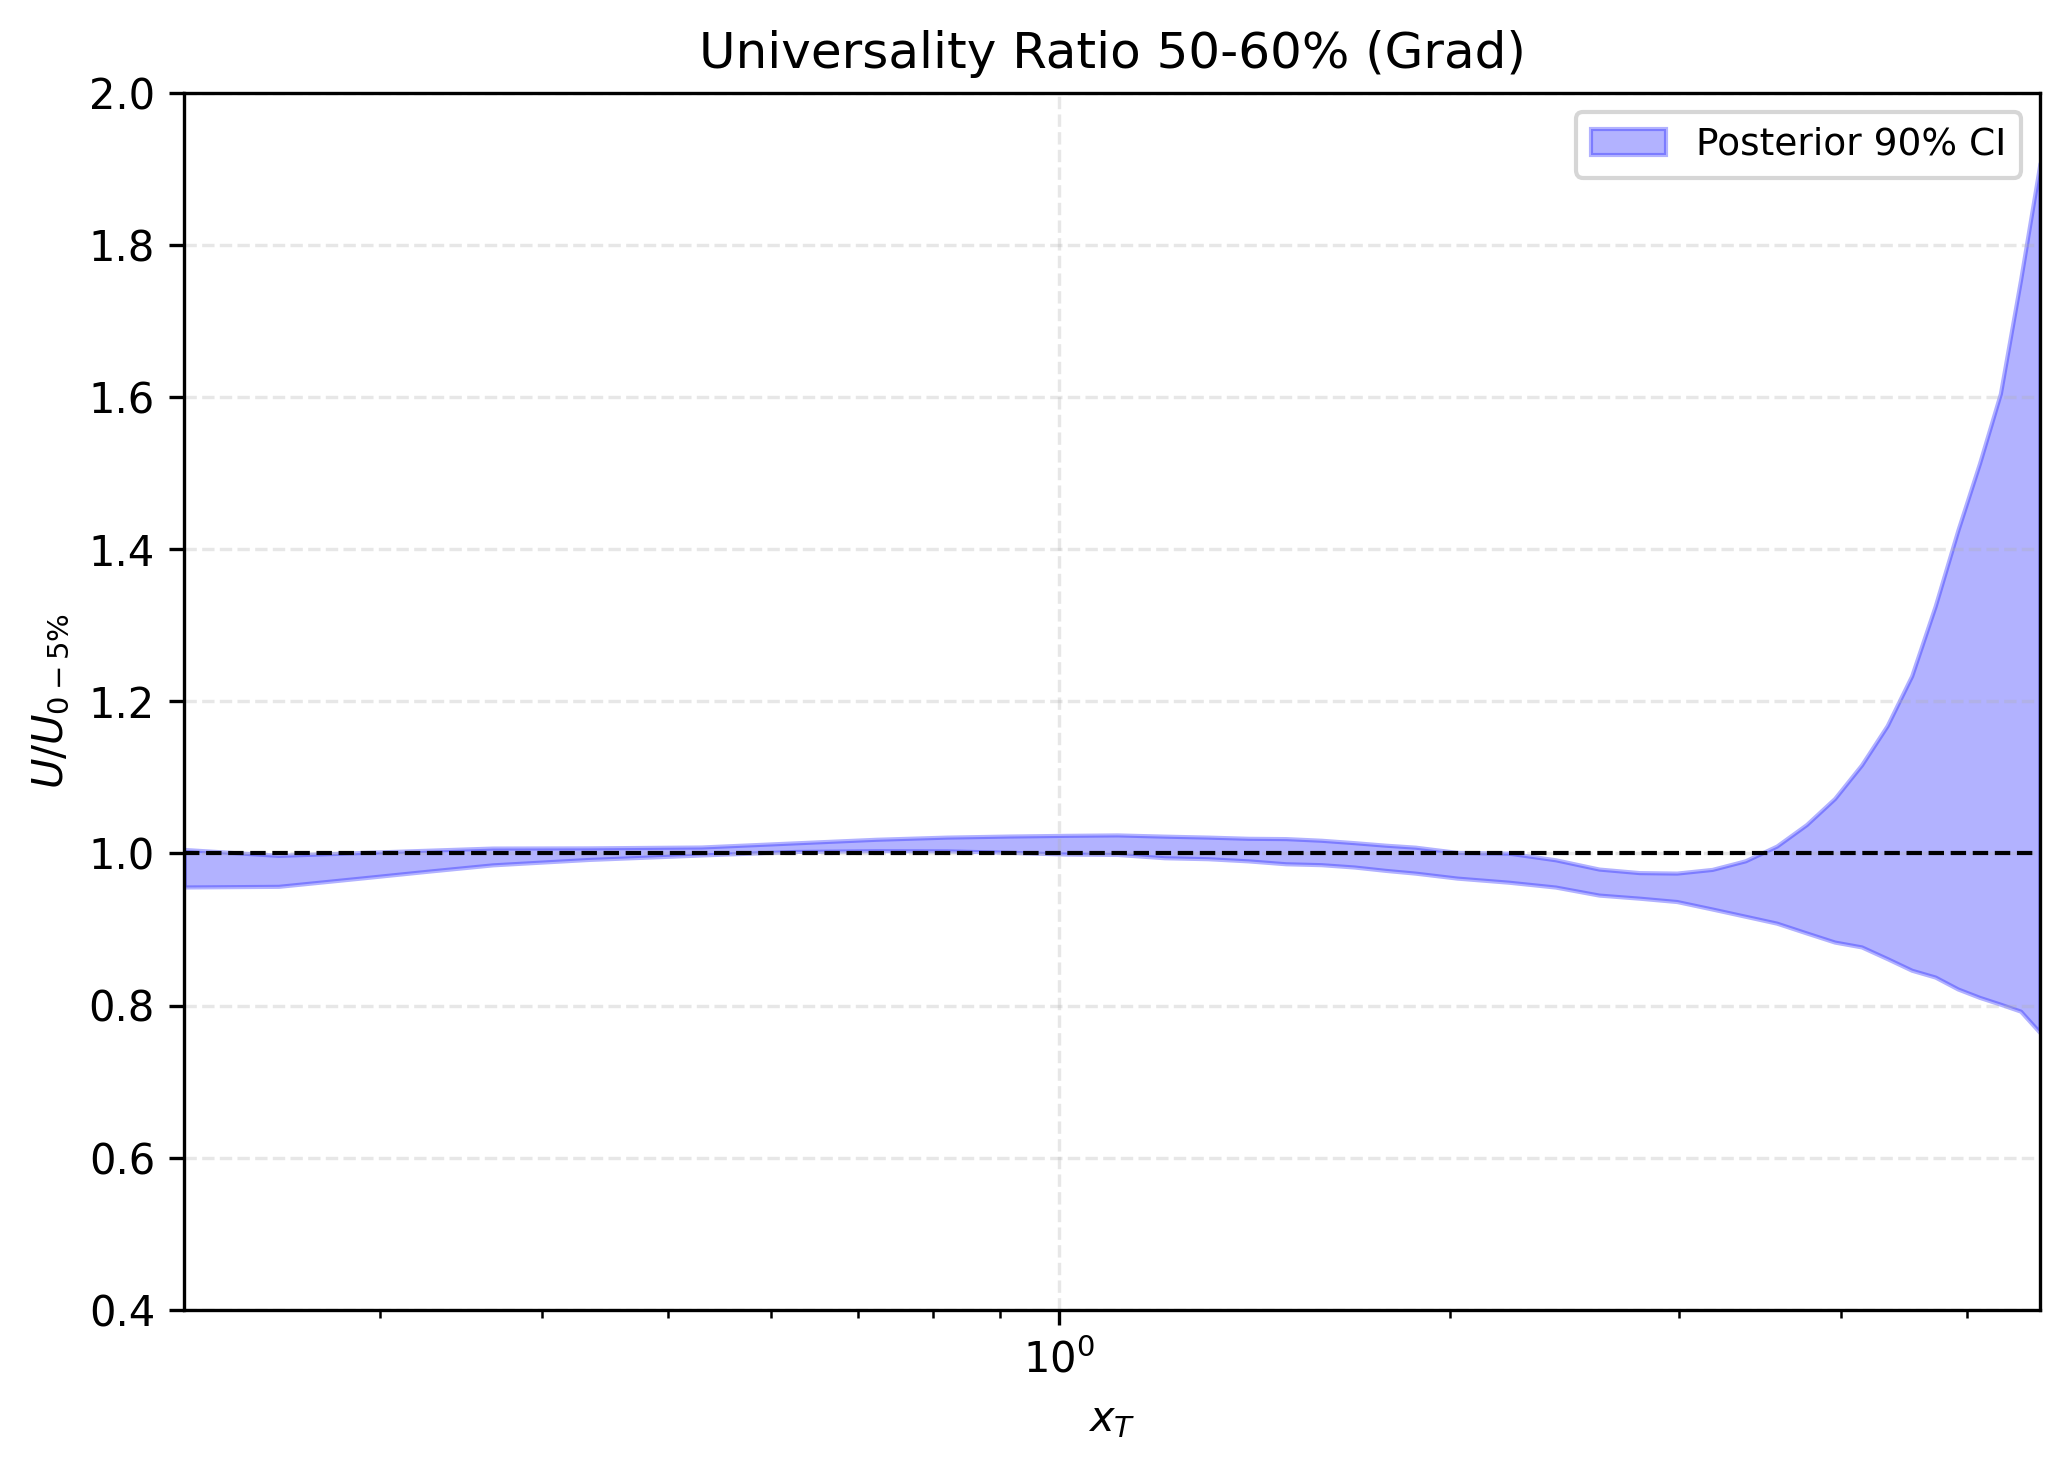

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

@plot
def plot_universality_for_centrality(
    idf,
    base_dir,
    cent_idx,                # índice da centralidade a plotar (1 = 5-10%, …)
    xT_experimental,
    ratios_experimental,
    ratios_uncertainties,
    posterior_samples=None,
    Emulators=None,
    inverse_tf_matrix=None,
    scaler=None,
    n_prior_samples=1000,
    n_posterior_samples=500,
    save_folder="universality"
):
    """
    Plota sobreposição de banda de prior, banda de posterior e pontos experimentais
    apenas para a centralidade especificada por cent_idx.
    """
    # carrega as curvas simuladas: shape = (n_design, n_cent_model, n_xt_model)
    calc_data = load_moment_data(base_dir, idf)
    n_design, n_model_cent, n_xt = calc_data.shape
    n_exp_cent = 7

    # grid de referência = xT experimental do 0-5%
    xT_ref = np.array(xT_experimental[0])

    # grade de target
    xT_tgt = np.array(xT_experimental[cent_idx])

    # prepara figura
    fig, ax = plt.subplots(figsize=(7,5), dpi=300)

    # 1) Banda de prior
#    prior_ratios = []
#    for i in range(min(n_prior_samples, n_design)):
#        U0 = calc_data[i, 0, :]
#        Ui = calc_data[i, cent_idx, :]
#        f0 = interpolate.interp1d(xT_ref, U0, fill_value="extrapolate")
#        fi = interpolate.interp1d(xT_tgt, Ui, fill_value="extrapolate")
#        prior_ratios.append(fi(xT_ref) / f0(xT_ref))
#    prior = np.stack(prior_ratios)
#    p_lo, p_hi = np.percentile(prior, [5,95], axis=0)
#    ax.fill_between(xT_ref, p_lo, p_hi, color='gray', alpha=0.5, label='Prior 90% CI')

    # 2) Banda de posterior (se houver)
    if posterior_samples is not None and Emulators is not None:
        post_ratios = []
        samp = posterior_samples.sample(n=min(n_posterior_samples, len(posterior_samples)))
        for _, row in samp.iterrows():
            y_pred, _ = predict_observables(row.values, Emulators, inverse_tf_matrix, scaler)
            # reconstrói shape (n_model_cent, n_xt)
            y_pred = y_pred.flatten().reshape(n_exp_cent, n_xt)
            U0, Ui = y_pred[0], y_pred[cent_idx]
            f0 = interpolate.interp1d(xT_ref, U0, fill_value="extrapolate")
            fi = interpolate.interp1d(xT_tgt, Ui, fill_value="extrapolate")
            post_ratios.append(fi(xT_ref) / f0(xT_ref))
        post = np.stack(post_ratios)
        q_lo, q_hi = np.percentile(post, [5,95], axis=0)
        ax.fill_between(xT_ref, q_lo, q_hi,
                        color=color_map[idf], alpha=0.3, label='Posterior 90% CI')

    # 3) Pontos experimentais
#    ax.errorbar(
#        xT_tgt,
#        ratios_experimental[cent_idx],
#        yerr=ratios_uncertainties[cent_idx],
#        fmt=exp_markers[cent_idx],
#        color='black',
#        capsize=3,
#        label='Experimental'
#    )

    # formatação
    ax.axhline(1, ls='--', color='k', lw=1)
    ax.set_xscale('log')
    ax.set_xlim(xT_ref.min(), xT_ref.max())
    ax.set_ylim(0.4, 2)
    ax.set_xlabel(r"$x_T$")
    ax.set_ylabel(r"$U/U_{0-5\%}$")
    ax.set_title(f"Universality Ratio {exp_centrality_labels[cent_idx]} ({idf_label_short[idf]})")
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # salva em pdf
#    out_dir = os.path.join(save_folder, f"idf_{idf}")
#    os.makedirs(out_dir, exist_ok=True)
#    out_file = os.path.join(out_dir, f"univ_ratio_cent{cent_idx}_idf{idf}.pdf")
#    fig.savefig(out_file, bbox_inches='tight')
#    plt.close(fig)
#    print(f"Saved overlay for centrality {exp_centrality_labels[cent_idx]} to {out_file}")
#    return out_file

centrality_classes=['0-5','5-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90']
xT=[[0.21215043,0.25072324,0.28929605,0.32786885,0.36644166,0.43394407,0.53037608,0.6268081,0.72324012,0.81967213,0.91610415,1.01253616,1.10896818,1.20540019,1.30183221,1.39826422,1.49469624,1.59112825,1.68756027,1.78399229,1.8804243,2.02507232,2.21793635,2.41080039,2.60366442,2.79652845,2.98939248,3.18225651,3.37512054,3.56798457,3.7608486,3.95371263,4.14657666,4.33944069,4.53230473,4.72516876,4.91803279,5.11089682,5.30376085,5.49662488,5.68948891],[0.21194605,0.2504817,0.28901734,0.32755299,0.36608863,0.43352601,0.52986513,0.62620424,0.72254335,0.81888247,0.91522158,1.01156069,1.10789981,1.20423892,1.30057803,1.39691715,1.49325626,1.58959538,1.68593449,1.7822736,1.87861272,2.02312139,2.21579961,2.40847784,2.60115607,2.7938343,2.98651252,3.17919075,3.37186898,3.56454721,3.75722543,3.94990366,4.14258189,4.33526012,4.52793834,4.72061657,4.9132948,5.10597303,5.29865125,5.49132948,5.68400771],[0.21194605,0.2504817,0.28901734,0.32755299,0.36608863,0.43352601,0.52986513,0.62620424,0.72254335,0.81888247,0.91522158,1.01156069,1.10789981,1.20423892,1.30057803,1.39691715,1.49325626,1.58959538,1.68593449,1.7822736,1.87861272,2.02312139,2.21579961,2.40847784,2.60115607,2.7938343,2.98651252,3.17919075,3.37186898,3.56454721,3.75722543,3.94990366,4.14258189,4.33526012,4.52793834,4.72061657,4.9132948,5.10597303,5.29865125,5.49132948,5.68400771],[0.21400778,0.25291829,0.29182879,0.3307393,0.36964981,0.43774319,0.53501946,0.63229572,0.72957198,0.82684825,0.92412451,1.02140078,1.11867704,1.21595331,1.31322957,1.41050584,1.5077821,1.60505837,1.70233463,1.79961089,1.89688716,2.04280156,2.23735409,2.43190661,2.62645914,2.82101167,3.0155642,3.21011673,3.40466926,3.59922179,3.79377432,3.98832685,4.18287938,4.37743191,4.57198444,4.76653696,4.96108949,5.15564202,5.35019455,5.54474708,5.73929961],[0.21760633,0.25717112,0.29673591,0.33630069,0.37586548,0.44510386,0.54401583,0.64292779,0.74183976,0.84075173,0.9396637,1.03857567,1.13748764,1.2363996,1.33531157,1.43422354,1.53313551,1.63204748,1.73095945,1.82987141,1.92878338,2.07715134,2.27497527,2.47279921,2.67062315,2.86844708,3.06627102,3.26409496,3.46191889,3.65974283,3.85756677,4.0553907,4.25321464,4.45103858,4.64886251,4.84668645,5.04451039,5.24233432,5.44015826,5.6379822,5.83580613],[0.22244692,0.26289181,0.3033367,0.3437816,0.38422649,0.45500506,0.55611729,0.65722952,0.75834176,0.85945399,0.96056623,1.06167846,1.1627907,1.26390293,1.36501517,1.4661274,1.56723964,1.66835187,1.76946411,1.87057634,1.97168857,2.12335693,2.3255814,2.52780586,2.73003033,2.9322548,3.13447927,3.33670374,3.53892821,3.74115268,3.94337715,4.14560162,4.34782609,4.55005056,4.75227503,4.95449949,5.15672396,5.35894843,5.5611729,5.76339737,5.96562184],[0.2289282,0.27055151,0.31217482,0.35379813,0.39542144,0.46826223,0.5723205,0.67637877,0.78043704,0.88449532,0.98855359,1.09261186,1.19667014,1.30072841,1.40478668,1.50884495,1.61290323,1.7169615,1.82101977,1.92507804,2.02913632,2.18522373,2.39334027,2.60145682,2.80957336,3.01768991,3.22580645,3.433923,3.64203954,3.85015609,4.05827263,4.26638918,4.47450572,4.68262227,4.89073881,5.09885536,5.3069719,5.51508845,5.72320499,5.93132154,6.13943809],[0.23529412,0.27807487,0.32085561,0.36363636,0.40641711,0.48128342,0.58823529,0.69518717,0.80213904,0.90909091,1.01604278,1.12299465,1.22994652,1.3368984,1.44385027,1.55080214,1.65775401,1.76470588,1.87165775,1.97860963,2.0855615,2.2459893,2.45989305,2.67379679,2.88770053,3.10160428,3.31550802,3.52941176,3.74331551,3.95721925,4.17112299,4.38502674,4.59893048,4.81283422,5.02673797,5.24064171,5.45454545,5.6684492,5.88235294,6.09625668,6.31016043],[0.24255788,0.28665932,0.33076075,0.37486218,0.41896362,0.49614112,0.60639471,0.71664829,0.82690187,0.93715546,1.04740904,1.15766262,1.26791621,1.37816979,1.48842337,1.59867696,1.70893054,1.81918412,1.92943771,2.03969129,2.14994487,2.31532525,2.53583241,2.75633958,2.97684675,3.19735391,3.41786108,3.63836825,3.85887541,4.07938258,4.29988975,4.52039691,4.74090408,4.96141125,5.18191841,5.40242558,5.62293275,5.84343991,6.06394708,6.28445424,6.50496141],[0.25200458,0.2978236,0.34364261,0.38946163,0.43528064,0.51546392,0.63001145,0.74455899,0.85910653,0.97365407,1.0882016,1.20274914,1.31729668,1.43184422,1.54639175,1.66093929,1.77548683,1.89003436,2.0045819,2.11912944,2.23367698,2.40549828,2.63459336,2.86368843,3.09278351,3.32187858,3.55097365,3.78006873,4.0091638,4.23825888,4.46735395,4.69644903,4.9255441,5.15463918,5.38373425,5.61282932,5.8419244,6.07101947,6.30011455,6.52920962,6.7583047]]
U_xT_ratios=[[1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.],[0.99212189,0.98176755,0.98307631,0.99205244,0.984027,1.00912513,1.00703253,1.00638534,1.00824875,1.00523946,1.00820496,0.99112851,0.99228336,0.99386802,0.99201651,0.99891989,0.99180681,0.99490301,1.00151065,0.99690049,0.9911244,0.99967504,0.99544152,0.99271021,0.99394593,0.99605267,1.00435109,0.99872795,0.99874636,1.00204439,1.00879312,1.0053233,1.01235574,1.02315089,1.01169808,1.01875078,1.02785821,1.01041896,1.05536579,1.04388088,1.0381409],[0.99125725,0.99093859,0.98781035,0.99469451,0.98680867,1.01645556,1.0099084,1.00415813,1.00546625,1.00302176,1.00238724,0.98705014,0.98765258,0.98859952,0.98621001,0.99083712,0.98629791,0.98693829,0.99082217,0.99214752,0.99068925,0.99467635,0.99649545,0.98760472,0.98873687,1.00499557,1.00766932,1.00333542,1.01184894,1.01131116,1.02140121,1.01584591,1.02791345,1.04567552,1.04136474,1.04487465,1.07546144,1.09380923,1.09157716,1.08338072,1.07882386],[1.00834829,0.99204605,0.99978412,1.00867267,0.99823855,1.01582727,1.00958659,1.00037758,0.99693593,0.99525866,0.99105336,0.97755381,0.97561875,0.97468912,0.97360652,0.97933343,0.9740168,0.97684591,0.97963037,0.98245854,0.98090287,0.98627341,0.98676523,0.98228168,0.98479082,1.0055581,1.02099957,1.02271064,1.0305555,1.03654439,1.0404762,1.06410942,1.07726973,1.10385865,1.08096315,1.13000197,1.12319467,1.14717515,1.18129303,1.17568761,1.18823712],[1.0165718,1.00225844,1.00942326,1.01171367,1.00627272,1.01801999,1.00824799,0.99701731,0.99191537,0.98858843,0.98128962,0.96605927,0.96051412,0.96478824,0.96381642,0.96139854,0.9606313,0.96475092,0.96256266,0.9647577,0.96844902,0.96964007,0.9702959,0.96904752,0.9827824,1.00238653,1.023381,1.02438821,1.04697581,1.05339988,1.07396763,1.09908395,1.14146292,1.12682816,1.14871235,1.21316435,1.20329084,1.24310295,1.24427051,1.29440042,1.33986227],[1.03940196,1.01895729,1.02533242,1.01520951,1.02295377,1.02731155,1.01586325,1.00403511,0.99148254,0.98701443,0.98268332,0.96057099,0.95433642,0.95386326,0.95818797,0.95282818,0.95192708,0.95435584,0.95693004,0.95500712,0.95250756,0.95439467,0.95526436,0.9747273,0.98031823,1.00845105,1.03490602,1.0488511,1.06948898,1.09443633,1.12385207,1.16754045,1.18254947,1.20812576,1.23901983,1.28691554,1.31960908,1.3619866,1.45796598,1.43155708,1.59839473],[1.03371307,1.03136478,1.04189153,1.02425534,1.02994622,1.03654665,1.02061918,1.00221379,0.98927533,0.98270808,0.97154527,0.95248128,0.93989869,0.94560828,0.94479093,0.94010751,0.94096093,0.93923871,0.93057958,0.93998821,0.94745753,0.94426388,0.94611435,0.96465844,1.0010537,1.01142701,1.04248375,1.07733438,1.09214087,1.14829351,1.18539621,1.20884908,1.25516159,1.27910417,1.35570371,1.39721984,1.49417424,1.52217812,1.53733135,1.61550463,2.099312],[1.0362942,1.05405706,1.0390795,1.03823098,1.06033081,1.04569242,1.02589563,1.00956363,0.98496305,0.98261679,0.96674042,0.94251465,0.92838444,0.92886758,0.92579186,0.92651063,0.91458939,0.92431782,0.91398247,0.92221047,0.92207178,0.92652719,0.92345434,0.95260745,0.99133803,1.00885506,1.04885622,1.10382735,1.11431166,1.19224774,1.24376068,1.27418187,1.33196294,1.38722144,1.47716096,1.53863093,1.6138456,1.66914024,1.77542724,2.04278606,3.07198689],[1.07579626,1.05018038,1.03974725,1.0323234,1.08132792,1.05984329,1.0356068,1.00850334,0.98877802,0.97483654,0.95791258,0.93144337,0.92164092,0.92045232,0.91793827,0.90906969,0.89587116,0.89381867,0.90075549,0.90019444,0.91653545,0.90651718,0.9339457,0.94948574,1.00378786,1.04254022,1.07258109,1.1286765,1.15357675,1.24684978,1.3283936,1.34187769,1.45095557,1.50713584,1.56874427,1.67075915,1.74032829,1.87919578,2.13474775,3.08097486,8.18087006],[1.02937051,1.04541699,1.03122067,1.06166564,1.08349452,1.09470481,1.05884016,1.03823895,1.01361936,0.99464515,0.97282835,0.93715081,0.92209546,0.92338648,0.91244016,0.90124944,0.9071594,0.88647144,0.86920525,0.90318733,0.89162476,0.90387072,0.92670181,0.95775217,0.98979986,1.0158362,1.06986393,1.12973251,1.15069727,1.26275439,1.30100188,1.38803538,1.50407289,1.5527221,1.64732166,1.76017378,1.99511176,2.37426167,3.16378579,9.60596765,-5.36633145]]
U_xT_ratios_uncertainties=[[0.1249408,0.12031706,0.11998557,0.11985535,0.12001958,0.09651751,0.09660579,0.09777901,0.09553545,0.09489954,0.09442881,0.088388,0.08782061,0.08842266,0.08861025,0.08861313,0.08893091,0.08899369,0.08927577,0.08942067,0.08915101,0.0896983,0.08962013,0.09139852,0.09145335,0.09175417,0.09202753,0.09241303,0.09279282,0.09326106,0.09397325,0.09477712,0.09574422,0.09650873,0.09764392,0.09978629,0.10115789,0.10366472,0.10419284,0.10590319,0.10904156],[0.11865703,0.11269834,0.11265902,0.11359851,0.11271451,0.09333393,0.09279933,0.09446892,0.09233086,0.09149617,0.09145332,0.08415623,0.08383635,0.08481639,0.08461678,0.08499717,0.08425163,0.08433354,0.08504978,0.08454714,0.08412242,0.0848842,0.08498603,0.08779444,0.08796935,0.08834286,0.08933144,0.08924515,0.08961739,0.09051265,0.091902,0.09244184,0.09398996,0.09580721,0.09590813,0.09881689,0.10112379,0.10209789,0.10723423,0.10793479,0.11092243],[0.11470693,0.10982285,0.10921752,0.1099003,0.10904297,0.09213908,0.09131854,0.09236892,0.09032325,0.08951338,0.08932846,0.08244405,0.08198893,0.08293326,0.08265056,0.08296853,0.08253343,0.08247968,0.08287513,0.08273649,0.08264501,0.08304707,0.0830993,0.08611003,0.08630014,0.08791747,0.08840846,0.08842762,0.08951572,0.09006514,0.09186682,0.09199737,0.09415263,0.09661031,0.0974392,0.10003343,0.10445121,0.10916921,0.10949947,0.1105174,0.11362713],[0.11231228,0.10539857,0.10605107,0.10689639,0.10574933,0.08937972,0.08863623,0.08927957,0.08694145,0.08627373,0.08570189,0.07919703,0.07854657,0.07980074,0.07954056,0.07980685,0.07942397,0.07956936,0.07971701,0.07983199,0.07972573,0.08018265,0.08016932,0.08359974,0.08393309,0.08591944,0.08750936,0.08797441,0.08918121,0.09025882,0.09144425,0.09429163,0.09660184,0.09996604,0.09904049,0.10619045,0.1072038,0.11254637,0.11650652,0.11796756,0.12334849],[0.11120284,0.10448001,0.1049659,0.1050709,0.10450568,0.08967692,0.08875037,0.08893077,0.08674297,0.08594391,0.08517367,0.07865873,0.07794269,0.07955939,0.07941083,0.07912841,0.07904478,0.07923629,0.07935688,0.07926776,0.07949627,0.07949106,0.07962871,0.08326673,0.08452697,0.08640139,0.08846773,0.08896255,0.09141689,0.09257263,0.0952613,0.09830846,0.10327965,0.10298935,0.10617157,0.11506631,0.11576569,0.12300823,0.12384047,0.13106732,0.1403319],[0.11232391,0.10469831,0.10505282,0.10403943,0.10490209,0.09101102,0.08980911,0.09016197,0.08744827,0.08651941,0.08598252,0.07937789,0.07857648,0.07986068,0.08005822,0.0795283,0.07967686,0.07965221,0.07983519,0.07963137,0.07945002,0.07949273,0.07955831,0.08490723,0.08551754,0.08811901,0.0907981,0.09243037,0.09470641,0.09758815,0.10111823,0.10590457,0.10860505,0.11189692,0.11629403,0.12372507,0.12892741,0.13670743,0.14729991,0.1471204,0.16996309],[0.11019383,0.1045685,0.10525086,0.10338382,0.10407584,0.09218896,0.09081703,0.09025834,0.0875818,0.08652477,0.08546189,0.0796442,0.07855416,0.08016374,0.0797948,0.07952166,0.07972063,0.07947167,0.07864268,0.07954857,0.08009203,0.07949977,0.07957426,0.08485612,0.08826008,0.08939697,0.09244218,0.09605373,0.09785109,0.1036354,0.10801003,0.11106621,0.11683504,0.12028106,0.12917792,0.13653349,0.14864781,0.15532342,0.15837552,0.16896624,0.22798808],[0.10647673,0.10233674,0.10060096,0.10039527,0.10254201,0.08968327,0.0878087,0.08760569,0.08405164,0.08348919,0.08226322,0.07575731,0.0745948,0.07601976,0.07570721,0.07595631,0.07486831,0.07569274,0.07474209,0.07559813,0.07548435,0.07562441,0.07535593,0.08129777,0.08473905,0.08649391,0.09028935,0.09560993,0.0970328,0.10460377,0.11023245,0.11399171,0.12080029,0.12715374,0.13733389,0.14703054,0.15714341,0.16720942,0.17964087,0.21041236,0.32868552],[0.12113519,0.1127539,0.11136044,0.11039661,0.11569343,0.10430924,0.10176841,0.10001136,0.09720429,0.0954338,0.09371866,0.08758654,0.0866127,0.08792413,0.08783791,0.08670562,0.0856885,0.08646926,0.08602605,0.08705737,0.08842435,0.08708097,0.08964658,0.09343719,0.0989309,0.10302217,0.10629329,0.1123376,0.11532383,0.12546063,0.13480672,0.13725221,0.14993391,0.15717501,0.16573882,0.1803367,0.19094103,0.21109988,0.24211693,0.35491928,0.97376035],[0.13368656,0.13071859,0.12872437,0.13237491,0.13512673,0.1295654,0.12551919,0.12343332,0.11976431,0.11730825,0.11479802,0.10803713,0.10679452,0.1074785,0.10638527,0.10487083,0.10603672,0.10334209,0.10326452,0.10687837,0.10596175,0.10593114,0.11026697,0.11345878,0.11741506,0.12072441,0.12747842,0.13509952,0.13811149,0.15229322,0.15803143,0.1697201,0.18561593,0.19326869,0.20727527,0.2256694,0.25930212,0.31474644,0.4260121,1.31321834,0.75679601]]

original_df = pd.read_csv("new_LHC_posterior_samples.csv")
posterior_original = original_df.iloc[:, :17]

# Exemplo: plotar apenas a razão 50–60% (cent_idx = -1) para idf=0
plot_universality_for_centrality(
    idf=0,
    base_dir='Bayesian_data',
    cent_idx=6,
    xT_experimental=xT,
    ratios_experimental=U_xT_ratios,
    ratios_uncertainties=U_xT_ratios_uncertainties,
    posterior_samples=posterior_original,
    Emulators=Emulators,
    inverse_tf_matrix=inverse_tf_matrix,
    scaler=scaler,
    n_prior_samples=1000,
    n_posterior_samples=posterior_original.shape[0],
    save_folder=folders['universality_ratio']
)
# (Universality plot: only one centrality)

### Matt's talk: Ulri birthday

Error reading file for design point 325: Bayesian_data/325/universal_alicecut_0.dat not found.
Error reading file for design point 327: Bayesian_data/327/universal_alicecut_0.dat not found.
Error reading file for design point 328: Bayesian_data/328/universal_alicecut_0.dat not found.
Error reading file for design point 329: Bayesian_data/329/universal_alicecut_0.dat not found.
Error reading file for design point 330: Bayesian_data/330/universal_alicecut_0.dat not found.
Error reading file for design point 331: Bayesian_data/331/universal_alicecut_0.dat not found.
Error reading file for design point 332: Bayesian_data/332/universal_alicecut_0.dat not found.
Error reading file for design point 333: Bayesian_data/333/universal_alicecut_0.dat not found.
Error reading file for design point 335: Bayesian_data/335/universal_alicecut_0.dat not found.
Error reading file for design point 336: Bayesian_data/336/universal_alicecut_0.dat not found.
Error reading file for design point 337: Bayesian_

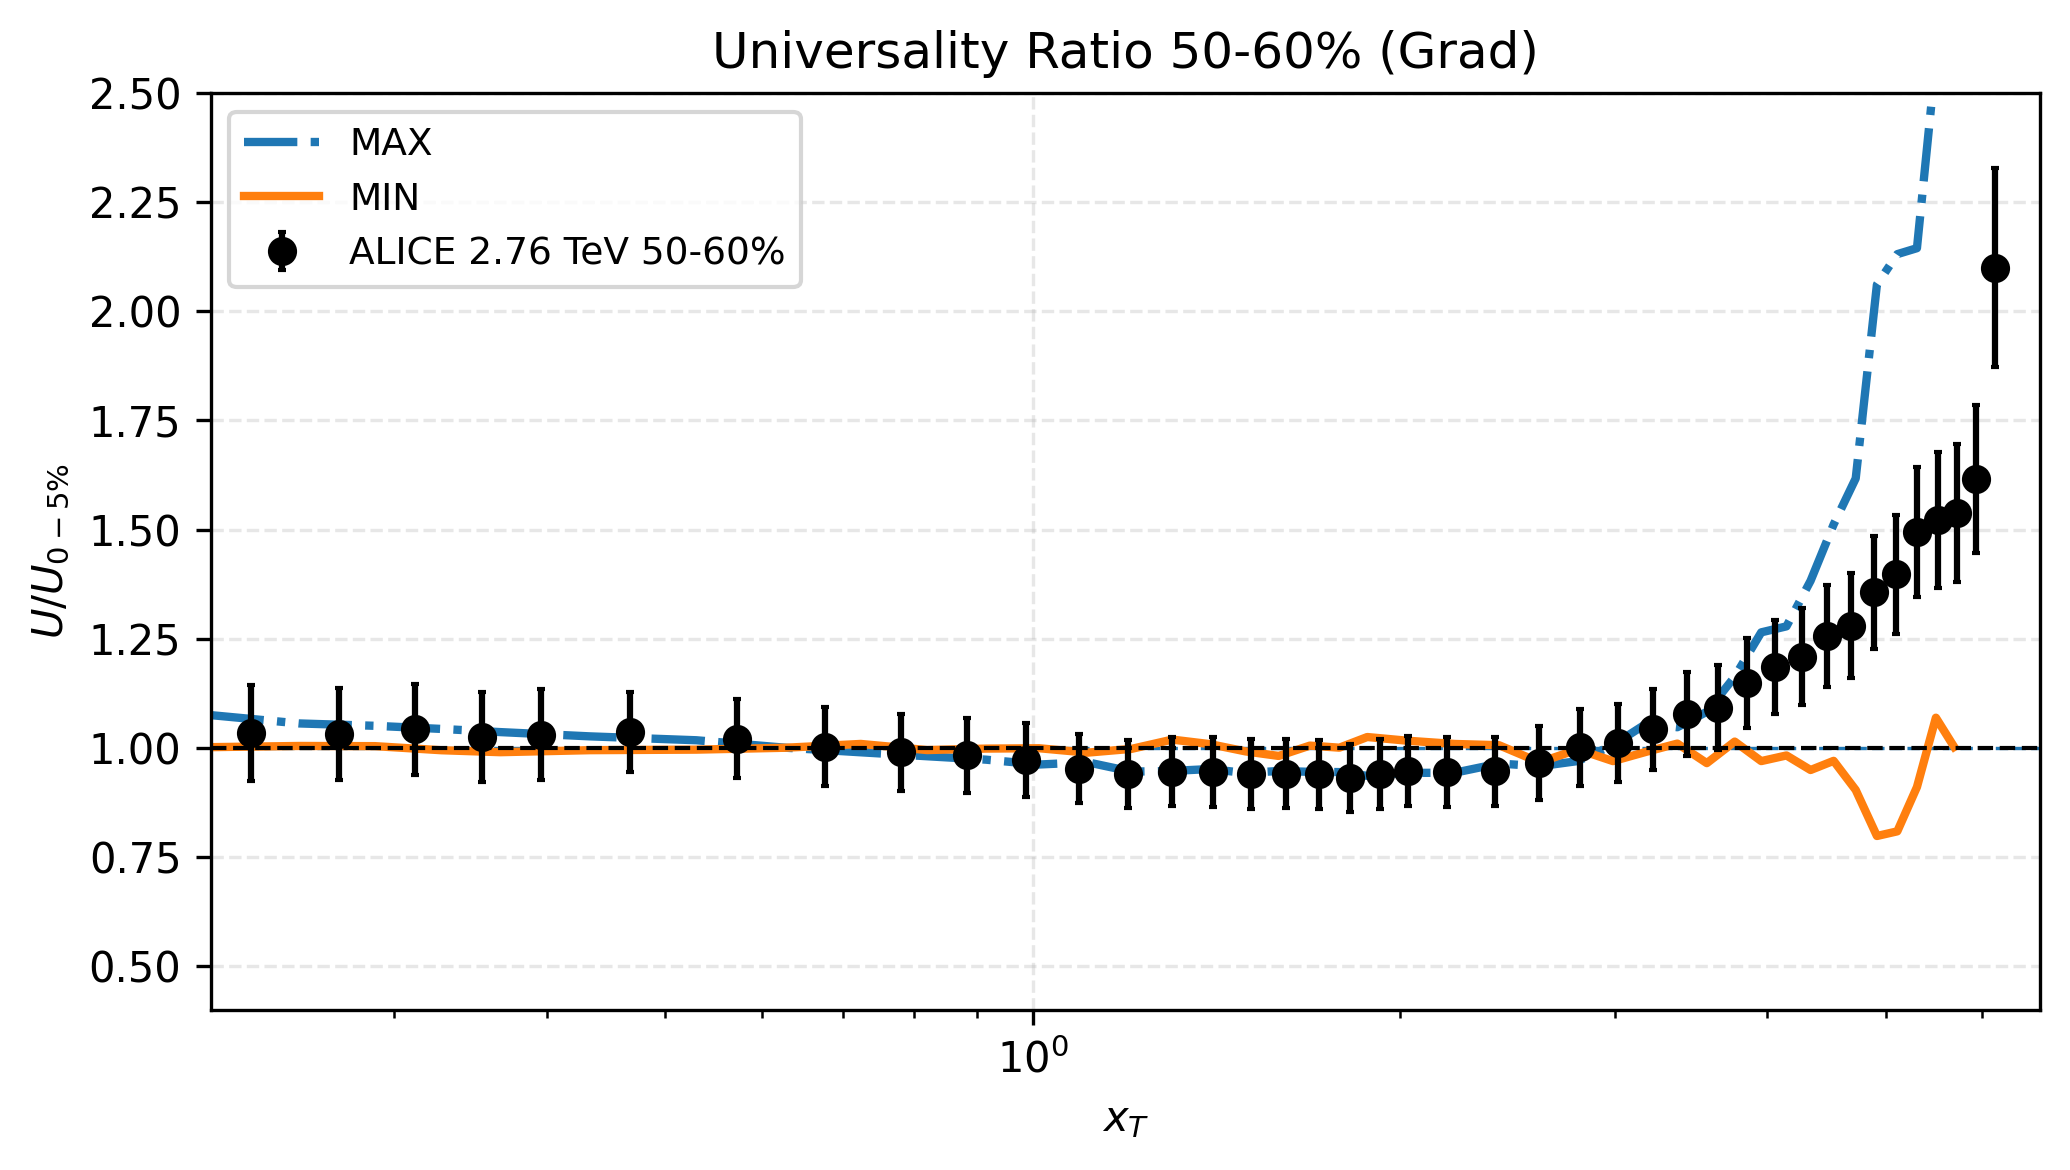

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

@plot
def plot_universality_for_centrality(
    idf,
    base_dir,
    cent_idx,                # índice da centralidade a plotar (1 = 5-10%, …)
    xT_experimental,
    ratios_experimental,
    ratios_uncertainties,
    posterior_samples=None,
    Emulators=None,
    inverse_tf_matrix=None,
    scaler=None,
    n_prior_samples=1000,
    n_posterior_samples=500,
    save_folder="universality"
):
    """
    Plota sobreposição de banda de prior, banda de posterior e pontos experimentais
    apenas para a centralidade especificada por cent_idx.
    """
    # carrega as curvas simuladas: shape = (n_design, n_cent_model, n_xt_model)
    calc_data = load_moment_data(base_dir, idf)
    n_design, n_model_cent, n_xt = calc_data.shape
    n_exp_cent = 7

    # grid de referência = xT experimental do 0-5%
    xT_ref = np.array(xT_experimental[0])

    # grade de target
    xT_tgt = np.array(xT_experimental[cent_idx])

    # 1) Banda de prior
    prior_ratios = []
    for i in range(min(n_prior_samples, n_design)):
        U0 = calc_data[i, 0, :]
        Ui = calc_data[i, cent_idx, :]
        f0 = interpolate.interp1d(xT_ref, U0, fill_value="extrapolate")
        fi = interpolate.interp1d(xT_tgt, Ui, fill_value="extrapolate")
        prior_ratios.append(fi(xT_ref) / f0(xT_ref))
    prior = np.stack(prior_ratios) # shape (n_samples, len(xT_ref))
        
    # --- Find global max/min and their sample/x indices ---
    max_idx_flat = int(np.argmax(np.abs(1-prior)))
    min_idx_flat = int(np.argmin(np.abs(1-prior)))
    max_sample_idx, max_x_idx = np.unravel_index(max_idx_flat, prior.shape)
    min_sample_idx, min_x_idx = np.unravel_index(min_idx_flat, prior.shape)
         
#    max_val = prior[max_sample_idx, max_x_idx]
#    min_val = prior[min_sample_idx, min_x_idx]
#    max_x = xT_ref[max_x_idx]
#    min_x = xT_ref[min_x_idx]
    
    max_params = load_design(idf).iloc[max_sample_idx]
    min_params = load_design(idf).iloc[min_sample_idx]
    
    print("\nParameters for MAX sample:\n", max_params.to_string())
    print("\nParameters for MIN sample:\n", min_params.to_string())
    
    # --- Plot only the two extrema points ---
    fig, ax = plt.subplots(figsize=(7,4), dpi=300)
    ax.axhline(1.0, linestyle='--', linewidth=0.8)
    ax.plot(xT_ref, prior[max_sample_idx, :], linestyle='-.', linewidth=2, label="MAX")
    ax.plot(xT_ref, prior[min_sample_idx, :], linestyle='-', linewidth=2, label="MIN")

    # experimental
    ax.errorbar(
        xT_experimental[cent_idx],
        ratios_experimental[cent_idx],
        yerr=ratios_uncertainties[cent_idx],
        fmt='o',
        color='k', 
        capsize=1,
        label=f"ALICE 2.76 TeV {centrality_classes[cent_idx]}%"
    )

           
    # formatação
    ax.axhline(1, ls='--', color='k', lw=1)
    ax.set_xscale('log')
    ax.set_xlim(xT_ref.min(), xT_ref.max()+1)
    ax.set_ylim(0.4, 2.5)
    ax.set_xlabel(r"$x_T$")
    ax.set_ylabel(r"$U/U_{0-5\%}$")
    ax.set_title(f"Universality Ratio {exp_centrality_labels[cent_idx]} ({idf_label_short[idf]})")
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('min_max_ratios_with_exp.pdf')
#    plt.show()
    
centrality_classes=['0-5','5-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90']

xT=[[0.21215043,0.25072324,0.28929605,0.32786885,0.36644166,0.43394407,0.53037608,0.6268081,0.72324012,0.81967213,0.91610415,1.01253616,1.10896818,1.20540019,1.30183221,1.39826422,1.49469624,1.59112825,1.68756027,1.78399229,1.8804243,2.02507232,2.21793635,2.41080039,2.60366442,2.79652845,2.98939248,3.18225651,3.37512054,3.56798457,3.7608486,3.95371263,4.14657666,4.33944069,4.53230473,4.72516876,4.91803279,5.11089682,5.30376085,5.49662488,5.68948891],[0.21194605,0.2504817,0.28901734,0.32755299,0.36608863,0.43352601,0.52986513,0.62620424,0.72254335,0.81888247,0.91522158,1.01156069,1.10789981,1.20423892,1.30057803,1.39691715,1.49325626,1.58959538,1.68593449,1.7822736,1.87861272,2.02312139,2.21579961,2.40847784,2.60115607,2.7938343,2.98651252,3.17919075,3.37186898,3.56454721,3.75722543,3.94990366,4.14258189,4.33526012,4.52793834,4.72061657,4.9132948,5.10597303,5.29865125,5.49132948,5.68400771],[0.21194605,0.2504817,0.28901734,0.32755299,0.36608863,0.43352601,0.52986513,0.62620424,0.72254335,0.81888247,0.91522158,1.01156069,1.10789981,1.20423892,1.30057803,1.39691715,1.49325626,1.58959538,1.68593449,1.7822736,1.87861272,2.02312139,2.21579961,2.40847784,2.60115607,2.7938343,2.98651252,3.17919075,3.37186898,3.56454721,3.75722543,3.94990366,4.14258189,4.33526012,4.52793834,4.72061657,4.9132948,5.10597303,5.29865125,5.49132948,5.68400771],[0.21400778,0.25291829,0.29182879,0.3307393,0.36964981,0.43774319,0.53501946,0.63229572,0.72957198,0.82684825,0.92412451,1.02140078,1.11867704,1.21595331,1.31322957,1.41050584,1.5077821,1.60505837,1.70233463,1.79961089,1.89688716,2.04280156,2.23735409,2.43190661,2.62645914,2.82101167,3.0155642,3.21011673,3.40466926,3.59922179,3.79377432,3.98832685,4.18287938,4.37743191,4.57198444,4.76653696,4.96108949,5.15564202,5.35019455,5.54474708,5.73929961],[0.21760633,0.25717112,0.29673591,0.33630069,0.37586548,0.44510386,0.54401583,0.64292779,0.74183976,0.84075173,0.9396637,1.03857567,1.13748764,1.2363996,1.33531157,1.43422354,1.53313551,1.63204748,1.73095945,1.82987141,1.92878338,2.07715134,2.27497527,2.47279921,2.67062315,2.86844708,3.06627102,3.26409496,3.46191889,3.65974283,3.85756677,4.0553907,4.25321464,4.45103858,4.64886251,4.84668645,5.04451039,5.24233432,5.44015826,5.6379822,5.83580613],[0.22244692,0.26289181,0.3033367,0.3437816,0.38422649,0.45500506,0.55611729,0.65722952,0.75834176,0.85945399,0.96056623,1.06167846,1.1627907,1.26390293,1.36501517,1.4661274,1.56723964,1.66835187,1.76946411,1.87057634,1.97168857,2.12335693,2.3255814,2.52780586,2.73003033,2.9322548,3.13447927,3.33670374,3.53892821,3.74115268,3.94337715,4.14560162,4.34782609,4.55005056,4.75227503,4.95449949,5.15672396,5.35894843,5.5611729,5.76339737,5.96562184],[0.2289282,0.27055151,0.31217482,0.35379813,0.39542144,0.46826223,0.5723205,0.67637877,0.78043704,0.88449532,0.98855359,1.09261186,1.19667014,1.30072841,1.40478668,1.50884495,1.61290323,1.7169615,1.82101977,1.92507804,2.02913632,2.18522373,2.39334027,2.60145682,2.80957336,3.01768991,3.22580645,3.433923,3.64203954,3.85015609,4.05827263,4.26638918,4.47450572,4.68262227,4.89073881,5.09885536,5.3069719,5.51508845,5.72320499,5.93132154,6.13943809],[0.23529412,0.27807487,0.32085561,0.36363636,0.40641711,0.48128342,0.58823529,0.69518717,0.80213904,0.90909091,1.01604278,1.12299465,1.22994652,1.3368984,1.44385027,1.55080214,1.65775401,1.76470588,1.87165775,1.97860963,2.0855615,2.2459893,2.45989305,2.67379679,2.88770053,3.10160428,3.31550802,3.52941176,3.74331551,3.95721925,4.17112299,4.38502674,4.59893048,4.81283422,5.02673797,5.24064171,5.45454545,5.6684492,5.88235294,6.09625668,6.31016043],[0.24255788,0.28665932,0.33076075,0.37486218,0.41896362,0.49614112,0.60639471,0.71664829,0.82690187,0.93715546,1.04740904,1.15766262,1.26791621,1.37816979,1.48842337,1.59867696,1.70893054,1.81918412,1.92943771,2.03969129,2.14994487,2.31532525,2.53583241,2.75633958,2.97684675,3.19735391,3.41786108,3.63836825,3.85887541,4.07938258,4.29988975,4.52039691,4.74090408,4.96141125,5.18191841,5.40242558,5.62293275,5.84343991,6.06394708,6.28445424,6.50496141],[0.25200458,0.2978236,0.34364261,0.38946163,0.43528064,0.51546392,0.63001145,0.74455899,0.85910653,0.97365407,1.0882016,1.20274914,1.31729668,1.43184422,1.54639175,1.66093929,1.77548683,1.89003436,2.0045819,2.11912944,2.23367698,2.40549828,2.63459336,2.86368843,3.09278351,3.32187858,3.55097365,3.78006873,4.0091638,4.23825888,4.46735395,4.69644903,4.9255441,5.15463918,5.38373425,5.61282932,5.8419244,6.07101947,6.30011455,6.52920962,6.7583047]]
U_xT_ratios=[[1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.],[0.99212189,0.98176755,0.98307631,0.99205244,0.984027,1.00912513,1.00703253,1.00638534,1.00824875,1.00523946,1.00820496,0.99112851,0.99228336,0.99386802,0.99201651,0.99891989,0.99180681,0.99490301,1.00151065,0.99690049,0.9911244,0.99967504,0.99544152,0.99271021,0.99394593,0.99605267,1.00435109,0.99872795,0.99874636,1.00204439,1.00879312,1.0053233,1.01235574,1.02315089,1.01169808,1.01875078,1.02785821,1.01041896,1.05536579,1.04388088,1.0381409],[0.99125725,0.99093859,0.98781035,0.99469451,0.98680867,1.01645556,1.0099084,1.00415813,1.00546625,1.00302176,1.00238724,0.98705014,0.98765258,0.98859952,0.98621001,0.99083712,0.98629791,0.98693829,0.99082217,0.99214752,0.99068925,0.99467635,0.99649545,0.98760472,0.98873687,1.00499557,1.00766932,1.00333542,1.01184894,1.01131116,1.02140121,1.01584591,1.02791345,1.04567552,1.04136474,1.04487465,1.07546144,1.09380923,1.09157716,1.08338072,1.07882386],[1.00834829,0.99204605,0.99978412,1.00867267,0.99823855,1.01582727,1.00958659,1.00037758,0.99693593,0.99525866,0.99105336,0.97755381,0.97561875,0.97468912,0.97360652,0.97933343,0.9740168,0.97684591,0.97963037,0.98245854,0.98090287,0.98627341,0.98676523,0.98228168,0.98479082,1.0055581,1.02099957,1.02271064,1.0305555,1.03654439,1.0404762,1.06410942,1.07726973,1.10385865,1.08096315,1.13000197,1.12319467,1.14717515,1.18129303,1.17568761,1.18823712],[1.0165718,1.00225844,1.00942326,1.01171367,1.00627272,1.01801999,1.00824799,0.99701731,0.99191537,0.98858843,0.98128962,0.96605927,0.96051412,0.96478824,0.96381642,0.96139854,0.9606313,0.96475092,0.96256266,0.9647577,0.96844902,0.96964007,0.9702959,0.96904752,0.9827824,1.00238653,1.023381,1.02438821,1.04697581,1.05339988,1.07396763,1.09908395,1.14146292,1.12682816,1.14871235,1.21316435,1.20329084,1.24310295,1.24427051,1.29440042,1.33986227],[1.03940196,1.01895729,1.02533242,1.01520951,1.02295377,1.02731155,1.01586325,1.00403511,0.99148254,0.98701443,0.98268332,0.96057099,0.95433642,0.95386326,0.95818797,0.95282818,0.95192708,0.95435584,0.95693004,0.95500712,0.95250756,0.95439467,0.95526436,0.9747273,0.98031823,1.00845105,1.03490602,1.0488511,1.06948898,1.09443633,1.12385207,1.16754045,1.18254947,1.20812576,1.23901983,1.28691554,1.31960908,1.3619866,1.45796598,1.43155708,1.59839473],[1.03371307,1.03136478,1.04189153,1.02425534,1.02994622,1.03654665,1.02061918,1.00221379,0.98927533,0.98270808,0.97154527,0.95248128,0.93989869,0.94560828,0.94479093,0.94010751,0.94096093,0.93923871,0.93057958,0.93998821,0.94745753,0.94426388,0.94611435,0.96465844,1.0010537,1.01142701,1.04248375,1.07733438,1.09214087,1.14829351,1.18539621,1.20884908,1.25516159,1.27910417,1.35570371,1.39721984,1.49417424,1.52217812,1.53733135,1.61550463,2.099312],[1.0362942,1.05405706,1.0390795,1.03823098,1.06033081,1.04569242,1.02589563,1.00956363,0.98496305,0.98261679,0.96674042,0.94251465,0.92838444,0.92886758,0.92579186,0.92651063,0.91458939,0.92431782,0.91398247,0.92221047,0.92207178,0.92652719,0.92345434,0.95260745,0.99133803,1.00885506,1.04885622,1.10382735,1.11431166,1.19224774,1.24376068,1.27418187,1.33196294,1.38722144,1.47716096,1.53863093,1.6138456,1.66914024,1.77542724,2.04278606,3.07198689],[1.07579626,1.05018038,1.03974725,1.0323234,1.08132792,1.05984329,1.0356068,1.00850334,0.98877802,0.97483654,0.95791258,0.93144337,0.92164092,0.92045232,0.91793827,0.90906969,0.89587116,0.89381867,0.90075549,0.90019444,0.91653545,0.90651718,0.9339457,0.94948574,1.00378786,1.04254022,1.07258109,1.1286765,1.15357675,1.24684978,1.3283936,1.34187769,1.45095557,1.50713584,1.56874427,1.67075915,1.74032829,1.87919578,2.13474775,3.08097486,8.18087006],[1.02937051,1.04541699,1.03122067,1.06166564,1.08349452,1.09470481,1.05884016,1.03823895,1.01361936,0.99464515,0.97282835,0.93715081,0.92209546,0.92338648,0.91244016,0.90124944,0.9071594,0.88647144,0.86920525,0.90318733,0.89162476,0.90387072,0.92670181,0.95775217,0.98979986,1.0158362,1.06986393,1.12973251,1.15069727,1.26275439,1.30100188,1.38803538,1.50407289,1.5527221,1.64732166,1.76017378,1.99511176,2.37426167,3.16378579,9.60596765,-5.36633145]]
U_xT_ratios_uncertainties=[[0.1249408,0.12031706,0.11998557,0.11985535,0.12001958,0.09651751,0.09660579,0.09777901,0.09553545,0.09489954,0.09442881,0.088388,0.08782061,0.08842266,0.08861025,0.08861313,0.08893091,0.08899369,0.08927577,0.08942067,0.08915101,0.0896983,0.08962013,0.09139852,0.09145335,0.09175417,0.09202753,0.09241303,0.09279282,0.09326106,0.09397325,0.09477712,0.09574422,0.09650873,0.09764392,0.09978629,0.10115789,0.10366472,0.10419284,0.10590319,0.10904156],[0.11865703,0.11269834,0.11265902,0.11359851,0.11271451,0.09333393,0.09279933,0.09446892,0.09233086,0.09149617,0.09145332,0.08415623,0.08383635,0.08481639,0.08461678,0.08499717,0.08425163,0.08433354,0.08504978,0.08454714,0.08412242,0.0848842,0.08498603,0.08779444,0.08796935,0.08834286,0.08933144,0.08924515,0.08961739,0.09051265,0.091902,0.09244184,0.09398996,0.09580721,0.09590813,0.09881689,0.10112379,0.10209789,0.10723423,0.10793479,0.11092243],[0.11470693,0.10982285,0.10921752,0.1099003,0.10904297,0.09213908,0.09131854,0.09236892,0.09032325,0.08951338,0.08932846,0.08244405,0.08198893,0.08293326,0.08265056,0.08296853,0.08253343,0.08247968,0.08287513,0.08273649,0.08264501,0.08304707,0.0830993,0.08611003,0.08630014,0.08791747,0.08840846,0.08842762,0.08951572,0.09006514,0.09186682,0.09199737,0.09415263,0.09661031,0.0974392,0.10003343,0.10445121,0.10916921,0.10949947,0.1105174,0.11362713],[0.11231228,0.10539857,0.10605107,0.10689639,0.10574933,0.08937972,0.08863623,0.08927957,0.08694145,0.08627373,0.08570189,0.07919703,0.07854657,0.07980074,0.07954056,0.07980685,0.07942397,0.07956936,0.07971701,0.07983199,0.07972573,0.08018265,0.08016932,0.08359974,0.08393309,0.08591944,0.08750936,0.08797441,0.08918121,0.09025882,0.09144425,0.09429163,0.09660184,0.09996604,0.09904049,0.10619045,0.1072038,0.11254637,0.11650652,0.11796756,0.12334849],[0.11120284,0.10448001,0.1049659,0.1050709,0.10450568,0.08967692,0.08875037,0.08893077,0.08674297,0.08594391,0.08517367,0.07865873,0.07794269,0.07955939,0.07941083,0.07912841,0.07904478,0.07923629,0.07935688,0.07926776,0.07949627,0.07949106,0.07962871,0.08326673,0.08452697,0.08640139,0.08846773,0.08896255,0.09141689,0.09257263,0.0952613,0.09830846,0.10327965,0.10298935,0.10617157,0.11506631,0.11576569,0.12300823,0.12384047,0.13106732,0.1403319],[0.11232391,0.10469831,0.10505282,0.10403943,0.10490209,0.09101102,0.08980911,0.09016197,0.08744827,0.08651941,0.08598252,0.07937789,0.07857648,0.07986068,0.08005822,0.0795283,0.07967686,0.07965221,0.07983519,0.07963137,0.07945002,0.07949273,0.07955831,0.08490723,0.08551754,0.08811901,0.0907981,0.09243037,0.09470641,0.09758815,0.10111823,0.10590457,0.10860505,0.11189692,0.11629403,0.12372507,0.12892741,0.13670743,0.14729991,0.1471204,0.16996309],[0.11019383,0.1045685,0.10525086,0.10338382,0.10407584,0.09218896,0.09081703,0.09025834,0.0875818,0.08652477,0.08546189,0.0796442,0.07855416,0.08016374,0.0797948,0.07952166,0.07972063,0.07947167,0.07864268,0.07954857,0.08009203,0.07949977,0.07957426,0.08485612,0.08826008,0.08939697,0.09244218,0.09605373,0.09785109,0.1036354,0.10801003,0.11106621,0.11683504,0.12028106,0.12917792,0.13653349,0.14864781,0.15532342,0.15837552,0.16896624,0.22798808],[0.10647673,0.10233674,0.10060096,0.10039527,0.10254201,0.08968327,0.0878087,0.08760569,0.08405164,0.08348919,0.08226322,0.07575731,0.0745948,0.07601976,0.07570721,0.07595631,0.07486831,0.07569274,0.07474209,0.07559813,0.07548435,0.07562441,0.07535593,0.08129777,0.08473905,0.08649391,0.09028935,0.09560993,0.0970328,0.10460377,0.11023245,0.11399171,0.12080029,0.12715374,0.13733389,0.14703054,0.15714341,0.16720942,0.17964087,0.21041236,0.32868552],[0.12113519,0.1127539,0.11136044,0.11039661,0.11569343,0.10430924,0.10176841,0.10001136,0.09720429,0.0954338,0.09371866,0.08758654,0.0866127,0.08792413,0.08783791,0.08670562,0.0856885,0.08646926,0.08602605,0.08705737,0.08842435,0.08708097,0.08964658,0.09343719,0.0989309,0.10302217,0.10629329,0.1123376,0.11532383,0.12546063,0.13480672,0.13725221,0.14993391,0.15717501,0.16573882,0.1803367,0.19094103,0.21109988,0.24211693,0.35491928,0.97376035],[0.13368656,0.13071859,0.12872437,0.13237491,0.13512673,0.1295654,0.12551919,0.12343332,0.11976431,0.11730825,0.11479802,0.10803713,0.10679452,0.1074785,0.10638527,0.10487083,0.10603672,0.10334209,0.10326452,0.10687837,0.10596175,0.10593114,0.11026697,0.11345878,0.11741506,0.12072441,0.12747842,0.13509952,0.13811149,0.15229322,0.15803143,0.1697201,0.18561593,0.19326869,0.20727527,0.2256694,0.25930212,0.31474644,0.4260121,1.31321834,0.75679601]]

# Exemplo: plotar apenas a razão 50–60% (cent_idx = -1) para idf=0
plot_universality_for_centrality(
    idf=0,
    base_dir='Bayesian_data',
    cent_idx=6,
    xT_experimental=xT,
    ratios_experimental=U_xT_ratios,
    ratios_uncertainties=U_xT_ratios_uncertainties,
    posterior_samples=None,
    Emulators=Emulators,
    inverse_tf_matrix=inverse_tf_matrix,
    scaler=scaler,
    n_prior_samples=1000,
    n_posterior_samples=None,
    save_folder=folders['universality_ratio']
)
# (Universality plot: only one centrality)